In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("StudentsPerformance.csv", encoding="latin1")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.isnull().sum()
df["math score"] = pd.to_numeric(df["math score"], errors="coerce")
df["reading score"] = pd.to_numeric(df["reading score"], errors="coerce")
df["writing score"] = pd.to_numeric(df["writing score"], errors="coerce")
df = df.dropna(subset=["math score", "reading score", "writing score"])
numeric_cols = ["math score", "reading score", "writing score"]
(df[numeric_cols] < 0).sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
avg_math = df["math score"].mean()
avg_read = df["reading score"].mean()
avg_write = df["writing score"].mean()

averages = {
"Math Average": avg_math,
"Reading Average": avg_read,
"Writing Average": avg_write
}
averages

{'Math Average': np.float64(66.089),
 'Reading Average': np.float64(69.169),
 'Writing Average': np.float64(68.054)}

In [11]:
df["total_score"] = df["math score"] + df["reading score"] + df["writing score"]

top_students = df.sort_values(by="total_score", ascending=False).head(5)
top_students

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
179,female,group D,some high school,standard,completed,97,100,100,297


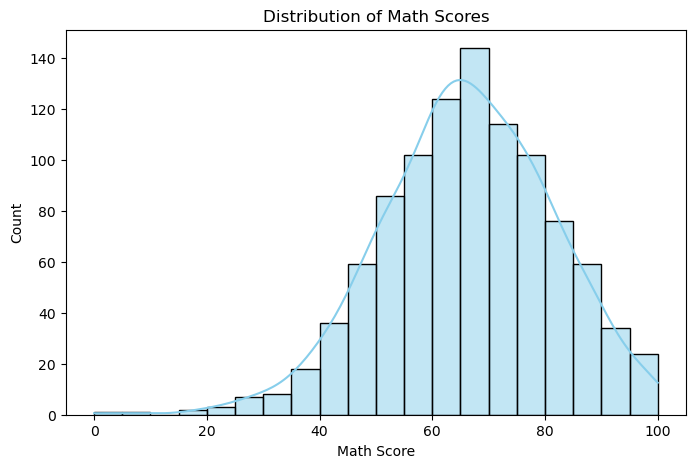

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["math score"], kde=True, bins=20, color="skyblue")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()


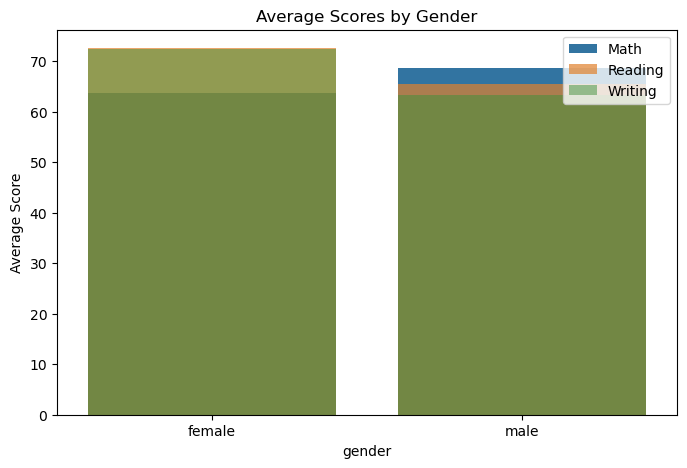

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="gender", y="math score", errorbar=None)
sns.barplot(data=df, x="gender", y="reading score", errorbar=None, alpha=0.7)
sns.barplot(data=df, x="gender", y="writing score", errorbar=None, alpha=0.5)

plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.legend(["Math", "Reading", "Writing"])
plt.show()


C:\Users\Pratham\AppData\Local\Temp\ipykernel_32536\2515335128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


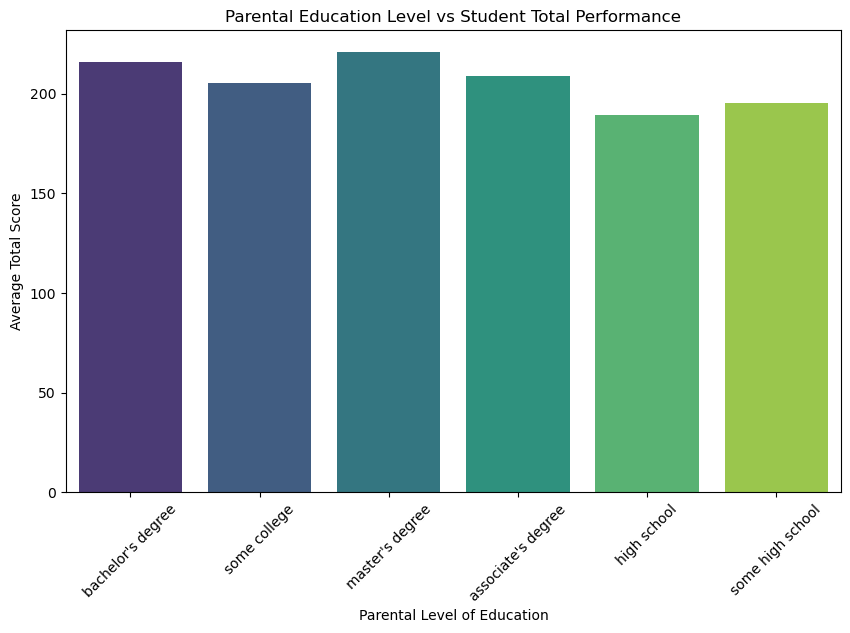

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="parental level of education",
    y="total_score",
    errorbar=None,
    palette="viridis"
)
plt.xticks(rotation=45)
plt.title("Parental Education Level vs Student Total Performance")
plt.ylabel("Average Total Score")
plt.xlabel("Parental Level of Education")
plt.show()


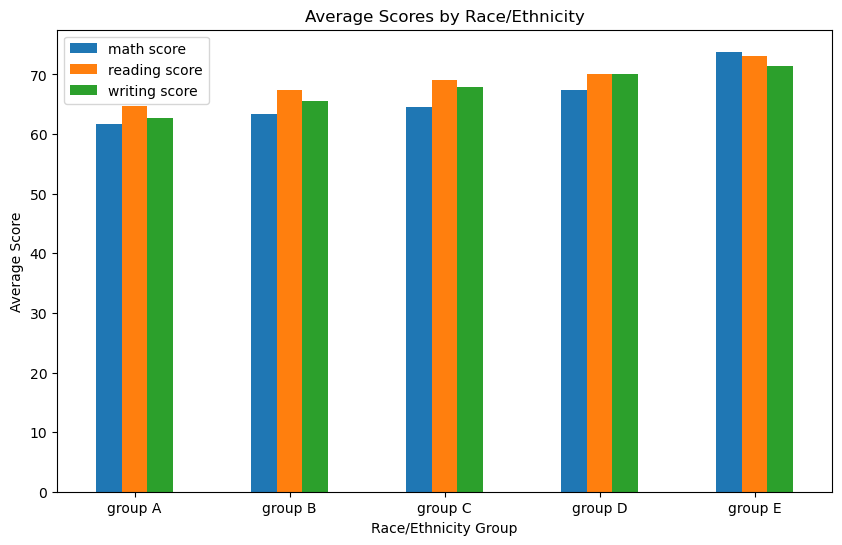

In [ ]:
race_scores = df.groupby("race/ethnicity")[["math score", "reading score", "writing score"]].mean()

race_scores.plot(kind="bar", figsize=(10,6))
plt.title("Average Scores by Race/Ethnicity")
plt.ylabel("Average Score")
plt.xlabel("Race/Ethnicity Group")
plt.xticks(rotation=0)
plt.show()
